In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

#import preprocessing functions
from src.preprocessing import preprocess

#import random forest specific functions
from src.random_forest import train_random_forest, test_random_forest
import shap

/home/jmastrandrea/anaconda3/envs/admet-project/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### This notebook will examine the preformance of random forest models on the ADMET dataset

In [3]:
# -- Raw training data
clean_train = preprocess(pd.read_csv("../data/raw/train_raw.csv") )

# -- Raw testing data
clean_test = preprocess(pd.read_csv("../data/raw/test_raw.csv"))

In [4]:
# --Defining targets and model/scores dictionaries
targets = []
for col in clean_train.columns:
    if col.startswith('log_'):
        targets.append(col)
    elif clean_train[col].dtype in ['float64', 'int64']:
        # Only add raw column if no log version exists
        log_version = f'log_{col}'
        if log_version not in clean_train.columns:
            targets.append(col)
            
rf_models = {}
rf_scores = {}
rf_data = {}

In [5]:
# -- Training
for target in targets:
    model, scores, X, y, y_pred_cv = train_random_forest(clean_train, target)
    rf_models[target] = model
    rf_scores[target] = scores
    rf_data[target] = (X, y, y_pred_cv)

In [6]:
# Iterate through both the target name and the model object
for target, model in rf_models.items():
    print(f"\n--- Summary for: {target} ---")
    
    # Use the model's built-in feature names
    summary_df = pd.DataFrame({
        'Feature': model.feature_names_in_,
        'Importance': model.feature_importances_
    })
    
    print(summary_df.to_string(index=False))
    #print(f"SHAP: {model.intercept_:.4f}")
    
    # Print the CV score too
    mean_score = rf_scores[target].mean()
    print(f"Mean CV R2: {mean_score:.4f}")


--- Summary for: LogD ---
      Feature  Importance
         KSOL    0.552227
log_HLM CLint    0.151261
log_MLM CLint    0.296512
Mean CV R2: 0.3253

--- Summary for: KSOL ---
      Feature  Importance
         LogD    0.456294
log_HLM CLint    0.225756
log_MLM CLint    0.317950
Mean CV R2: -0.2603

--- Summary for: log_HLM CLint ---
      Feature  Importance
         LogD    0.195577
         KSOL    0.249459
log_MLM CLint    0.554964
Mean CV R2: -0.8353

--- Summary for: log_MLM CLint ---
      Feature  Importance
         LogD    0.231353
         KSOL    0.315014
log_HLM CLint    0.453633
Mean CV R2: 0.0833


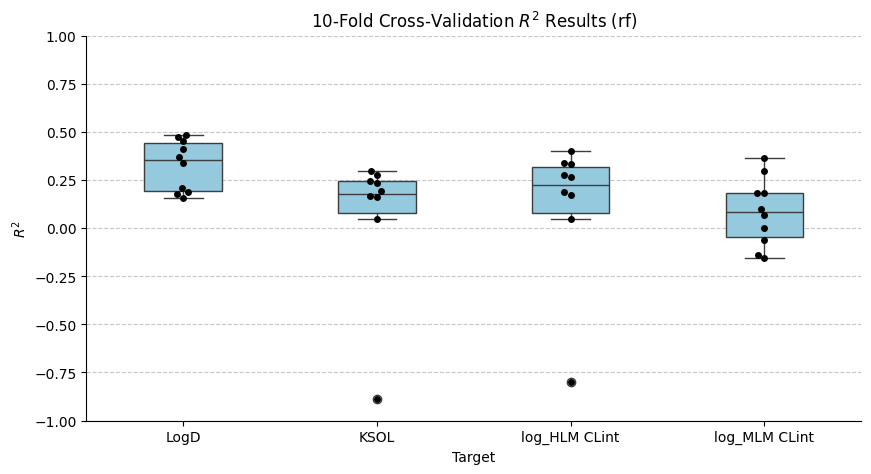

In [7]:
scores_df_rf = pd.DataFrame(rf_scores)

plt.figure(figsize=(10, 5))
sns.boxplot(data=scores_df_rf, color='skyblue', width=0.4)
sns.swarmplot(data=scores_df_rf, color='black')

plt.title(r'10-Fold Cross-Validation $R^2$ Results (rf)')
plt.ylabel(r'$R^2$')
plt.ylim(-1,1)
plt.xlabel('Target')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()

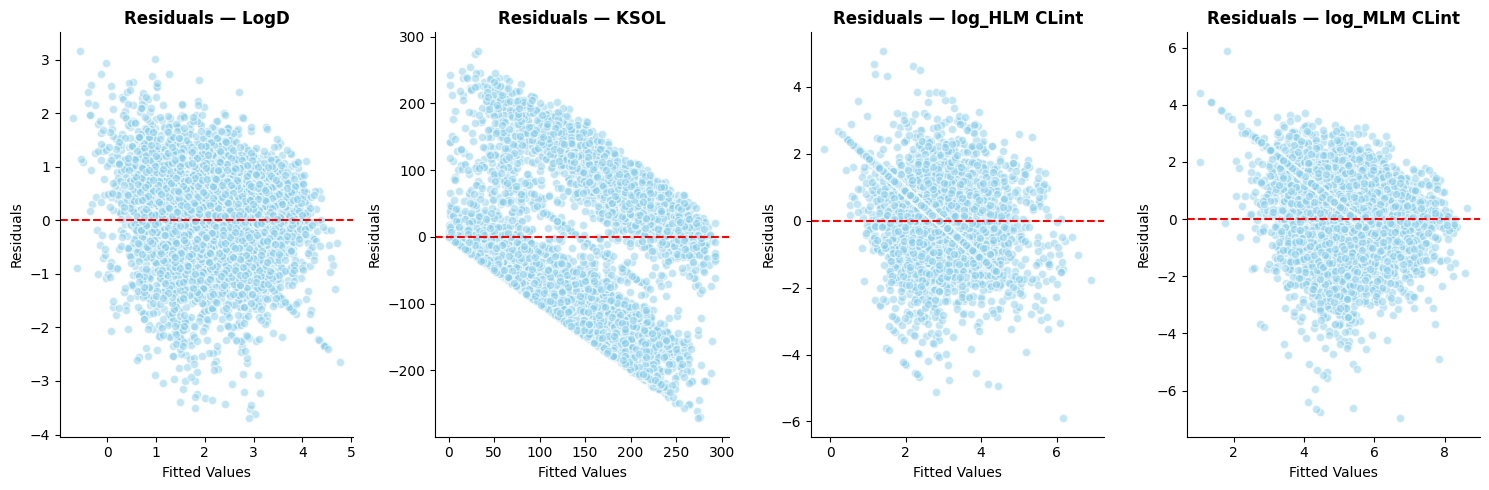

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, (target, model) in zip(axes, rf_models.items()):
    X, y, y_pred_cv = rf_data[target]
    residuals = y - y_pred_cv
    ax.scatter(y_pred_cv, residuals, alpha=0.5, color='skyblue', edgecolors='white')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_title(f'Residuals — {target}', fontweight='bold')
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Similar heteroskedasticity as was seen with linear regression/lasso models

In [9]:
rf_pred = {} #dictionary to hold the predictions from each model
rf_resid = {} #dictionary to hold the residuals for later convience
for target in rf_models.keys():
    #predict each target using its respective trained lasso regression model and store results in the rf_pred dictionary
    rf_pred[target] = test_random_forest(clean_test,target, rf_models[target])

    residuals = rf_pred[target] - clean_test[target] #calcualte residuals
    rf_resid[target] = residuals #store resids

LogD | $R^2 = 0.645$
KSOL | $R^2 = 0.593$
log_HLM CLint | $R^2 = 0.699$
log_MLM CLint | $R^2 = 0.692$


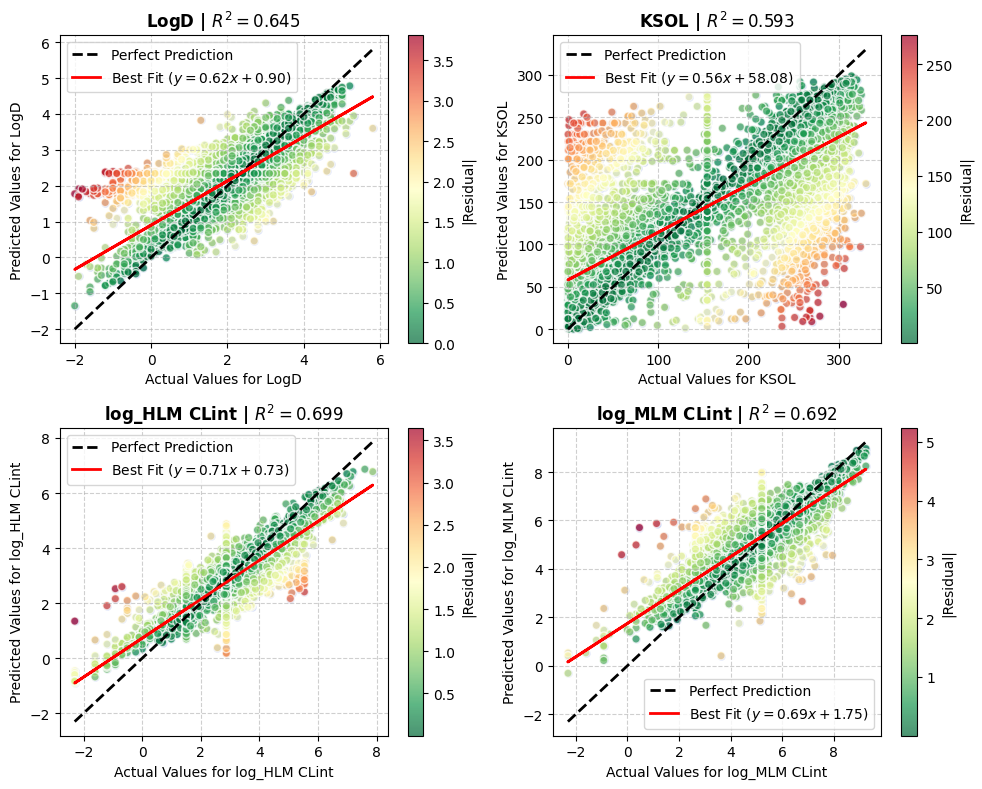

In [14]:
# Plot test results for each Lasso model
fig, axs = plt.subplots(2, 2, figsize=(10, 8)) #Set axis
axs_flat = axs.flatten()  #flatten to use in loop

for i, target in enumerate(rf_pred.keys()):
    ax = axs_flat[i]
    y_pred = rf_pred[target]
    y_real = clean_test[target]
    r2 = r2_score(y_real, y_pred) #calculate r2
    m, b = np.polyfit(y_real, y_pred, 1)
    ax.scatter(y_real, y_pred, alpha=0.5, color='royalblue', edgecolors='w')
    residuals = abs(rf_resid[target])
    scatter = ax.scatter(y_real, y_pred, c=residuals, cmap='RdYlGn_r', #colour the residuals based on proximity to perfect prediction
                     alpha=0.7, edgecolors='w')
    plt.colorbar(scatter, ax=ax, label='|Residual|')
    min_val = min(min(y_real), min(y_pred))
    max_val = max(max(y_real), max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction') #line representing perfect prediction
    ax.plot(y_real, m * y_real + b, color='red', lw=2, label=f'Best Fit ($y={m:.2f}x{b:+.2f}$)') #line of best fit

    ax.set_xlabel(f'Actual Values for {target}')
    ax.set_ylabel(f'Predicted Values for {target}')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    ax.set_title(f'{target} | $R^2 = {r2:.3f}$', fontsize=12, fontweight='bold')

    print(f'{target} | $R^2 = {r2:.3f}$')

plt.tight_layout()
plt.show()

In [15]:
clean_test_copy = preprocess(pd.read_csv("../data/raw/test_raw.csv"))
print(clean_test_copy.columns.tolist())

['Molecule Name', 'SMILES', 'LogD', 'KSOL', 'LogD_censored', 'KSOL_censored', 'HLM CLint_censored', 'RLM CLint_censored', 'MLM CLint_censored', 'Caco-2 Permeability Papp A>B_censored', 'Caco-2 Permeability Efflux_censored', 'MPPB_censored', 'MBPB_censored', 'MGMB_censored', 'log_HLM CLint', 'log_MLM CLint']


In [16]:

clean_test_copy = preprocess(pd.read_csv("../data/raw/test_raw.csv"))
print(clean_test_copy.columns.tolist())

['Molecule Name', 'SMILES', 'LogD', 'KSOL', 'LogD_censored', 'KSOL_censored', 'HLM CLint_censored', 'RLM CLint_censored', 'MLM CLint_censored', 'Caco-2 Permeability Papp A>B_censored', 'Caco-2 Permeability Efflux_censored', 'MPPB_censored', 'MBPB_censored', 'MGMB_censored', 'log_HLM CLint', 'log_MLM CLint']
